In [2]:
from misc import *
import constant

In [3]:
# upto 5 long track candidates isMuon
LTRACK5_HIGH_MASS_FILE_PATH = "/dice/projects/LHCb/PbPb_MSCi/LeadLead_dimuon_HighMass_all.root"
DEFAULT_TREE_NAME = "dimuonTuple/DecayTree"

no_ismuon_df = load_root(LTRACK5_HIGH_MASS_FILE_PATH, DEFAULT_TREE_NAME)
df = no_ismuon_df[(no_ismuon_df["muplus_isMuon"] == True) & (no_ismuon_df["muminus_isMuon"] == True)]

In [4]:
def add_upsilon(ax, xS):
    for i in xS:
        mass = eval(f"constant.UPSILON_{i}S_MASS")
        label = r"$M(\Upsilon\mathrm{(" + f"{i}" + r"S)})$"
        ax.axvline(mass, color="k", linewidth=1.5, label=label, ls="--")

In [5]:
half_mass_range = 53 # 1 std
upsilon_1S_df = df[(df["J_psi_1S_M"] > constant.UPSILON_1S_MASS - half_mass_range) & (df["J_psi_1S_M"] < constant.UPSILON_1S_MASS + half_mass_range)]
upsilon_2S_df = df[(df["J_psi_1S_M"] > constant.UPSILON_2S_MASS - half_mass_range) & (df["J_psi_1S_M"] < constant.UPSILON_2S_MASS + half_mass_range)]
upsilon_3S_df = df[(df["J_psi_1S_M"] > constant.UPSILON_3S_MASS - half_mass_range) & (df["J_psi_1S_M"] < constant.UPSILON_3S_MASS + half_mass_range)]
background_df = df[(df["J_psi_1S_M"] > 12_000)] #& (df["J_psi_1S_M"] < 20_000)]

In [6]:
import vector

def helicity_angles(
    vector1: vector.VectorNumpy,
    vector2: vector.VectorNumpy,
):
    """
    based off https://gaugeinvariant.wordpress.com/2012/03/21/helicity-angle-calculations/

    cos(theta_h) = p_mu_com.p_com / (|p_mu_com| |p_com|)
    """

    com_vector = vector1 + vector2

    # Apply boost into CoM/Upsilon frame
    vector1_com = vector1.boostCM_of(com_vector)
    vector2_com = vector2.boostCM_of(com_vector)

    # determine helicities
    cos_helicity_angle_1 = vector1_com.dot(com_vector) / (
        vector1_com.mag * com_vector.mag
    )
    cos_helicity_angle_2 = vector2_com.dot(com_vector) / (
        vector2_com.mag * com_vector.mag
    )

    # also calcuate arccos(cos(helicity angle))
    # many candidates are removed as outputs are nan
    helicity_angle_1 = np.acos(cos_helicity_angle_1)
    helicity_angle_1 = helicity_angle_1[np.isfinite(helicity_angle_1)]

    helicity_angle_2 = np.acos(cos_helicity_angle_2)
    helicity_angle_2 = helicity_angle_2[np.isfinite(helicity_angle_2)]

    return (cos_helicity_angle_1, helicity_angle_1), (
        cos_helicity_angle_2,
        helicity_angle_2,
    )


muplus_vector = vector.array(
    {
        "px": df["muplus_PX"],
        "py": df["muplus_PY"],
        "pz": df["muplus_PZ"],
        "mass": df["muplus_M"],
    }
)
muminus_vector = vector.array(
    {
        "px": df["muminus_PX"],
        "py": df["muminus_PY"],
        "pz": df["muminus_PZ"],
        "mass": df["muminus_M"],
    }
)

(cos_helicity_muplus, helicity_muplus), (cos_helicity_muminus, helicity_muminus) = (
    helicity_angles(muplus_vector, muminus_vector)
)

/tmp/ipykernel_2093993/2004014895.py:29: RuntimeWarning: invalid value encountered in arccos
  helicity_angle_1 = np.acos(cos_helicity_angle_1)
/tmp/ipykernel_2093993/2004014895.py:32: RuntimeWarning: invalid value encountered in arccos
  helicity_angle_2 = np.acos(cos_helicity_angle_2)


# Plot helicity angle $\theta_h$

Differing numbers of candidates due to arccos returning nans

Histogram not saved to file


<Axes: xlabel='$\\theta_H$', ylabel='Candidates (Normalised)'>

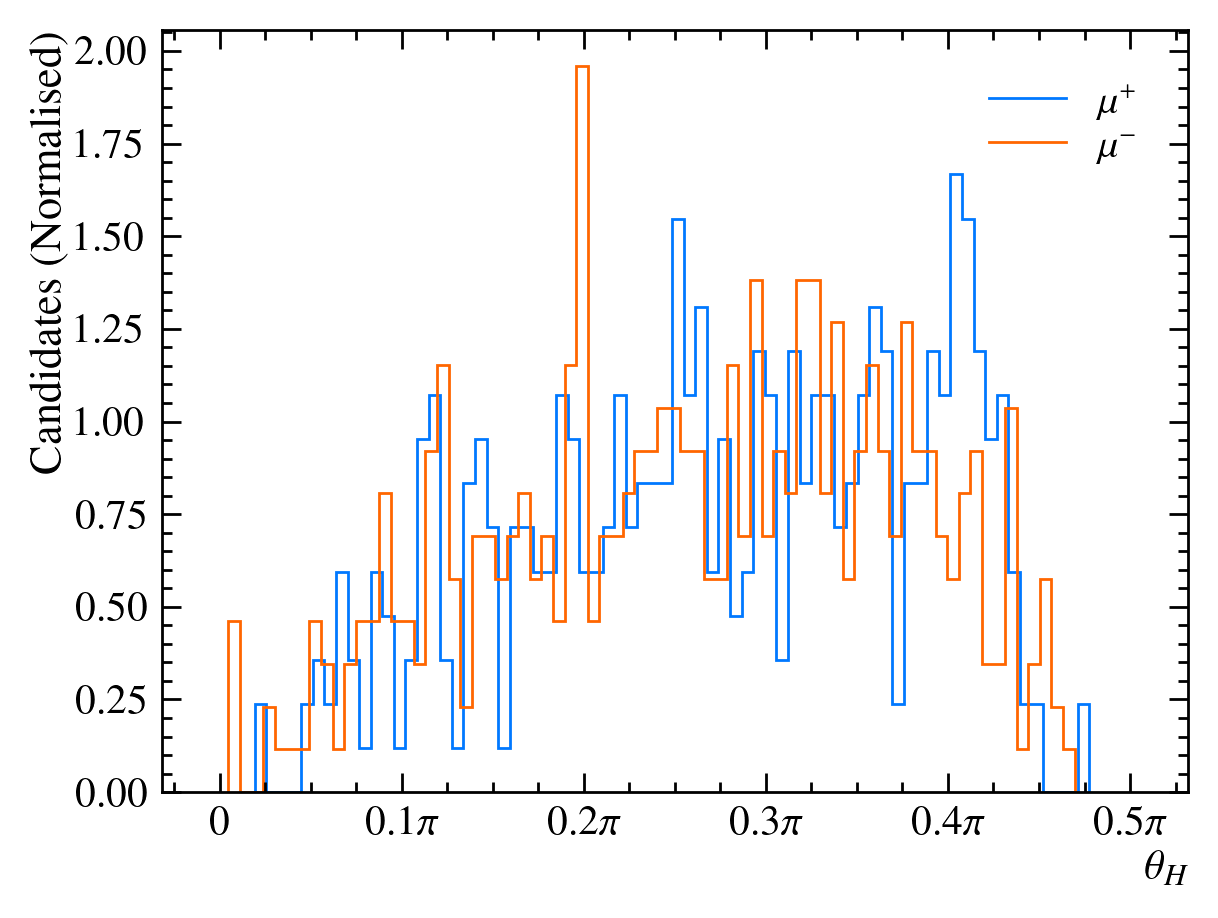

In [7]:
fig, ax = histogram_fig(
    [
        HistogramPlot(helicity_muplus, r"$\mu^+$", bins=0.02),
        HistogramPlot(helicity_muminus, r"$\mu^-$", bins=0.02),
    ],
    False,
    density=True,
    xlabel=r"$\theta_H$",
    xlim=[-0.1, np.pi/2 + 0.1]
)
ax_units_pi(ax)

# Plot $\cos(\theta_h)$

Histogram not saved to file


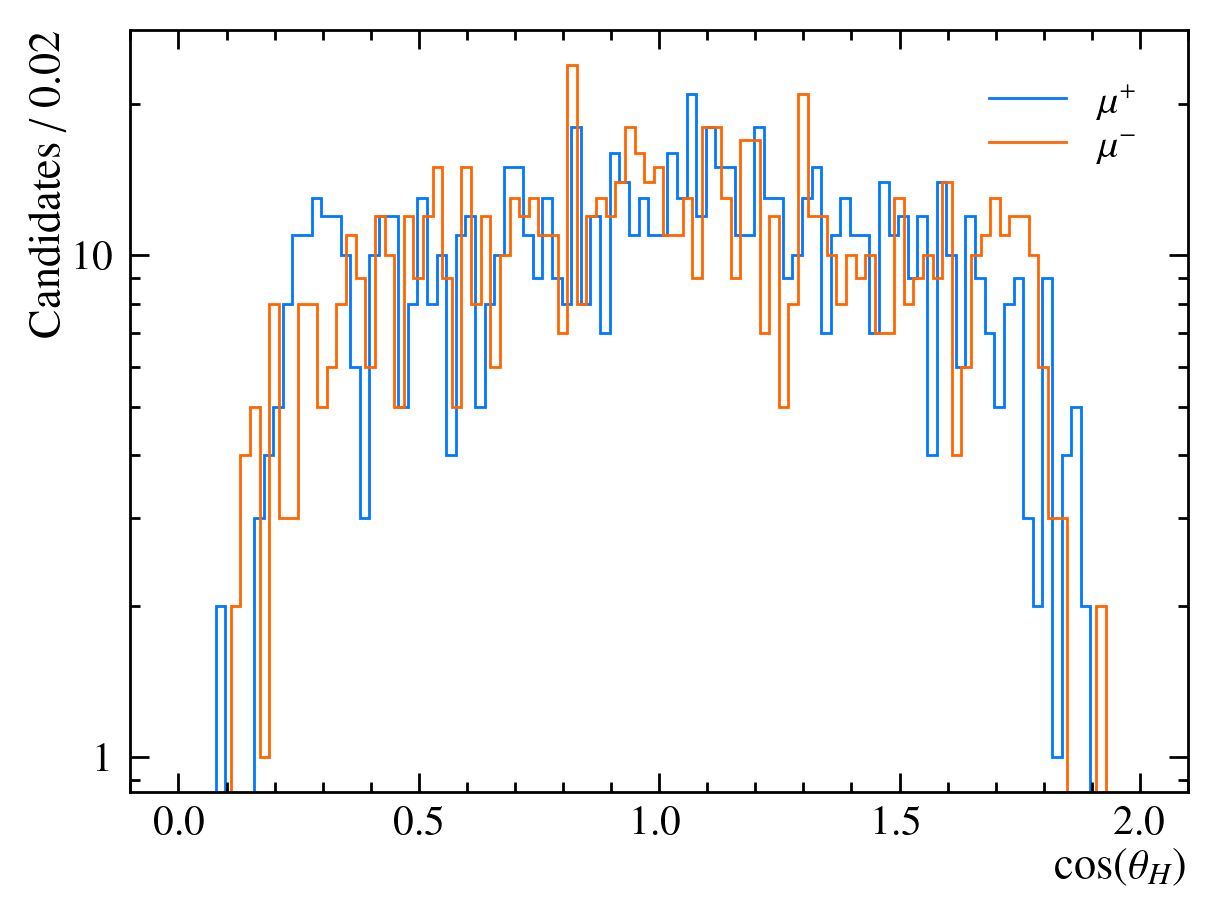

In [8]:
fig, ax = histogram_fig(
    [
        HistogramPlot(cos_helicity_muplus, r"$\mu^+$", bins=0.02),
        HistogramPlot(cos_helicity_muminus, r"$\mu^-$", bins=0.02),
    ],
    False,
    xlabel=r"$\cos(\theta_H)$",
    xlim=[-0.1, 2.1]
)
ax.set_yscale("log")


# Comparing entire dataset with `isMuon` cut

Histogram not saved to file
Histogram not saved to file


/tmp/ipykernel_2093993/2004014895.py:29: RuntimeWarning: invalid value encountered in arccos
  helicity_angle_1 = np.acos(cos_helicity_angle_1)
/tmp/ipykernel_2093993/2004014895.py:32: RuntimeWarning: invalid value encountered in arccos
  helicity_angle_2 = np.acos(cos_helicity_angle_2)


<Axes: xlabel='$\\theta_h$', ylabel='Candidates (Normalised)'>

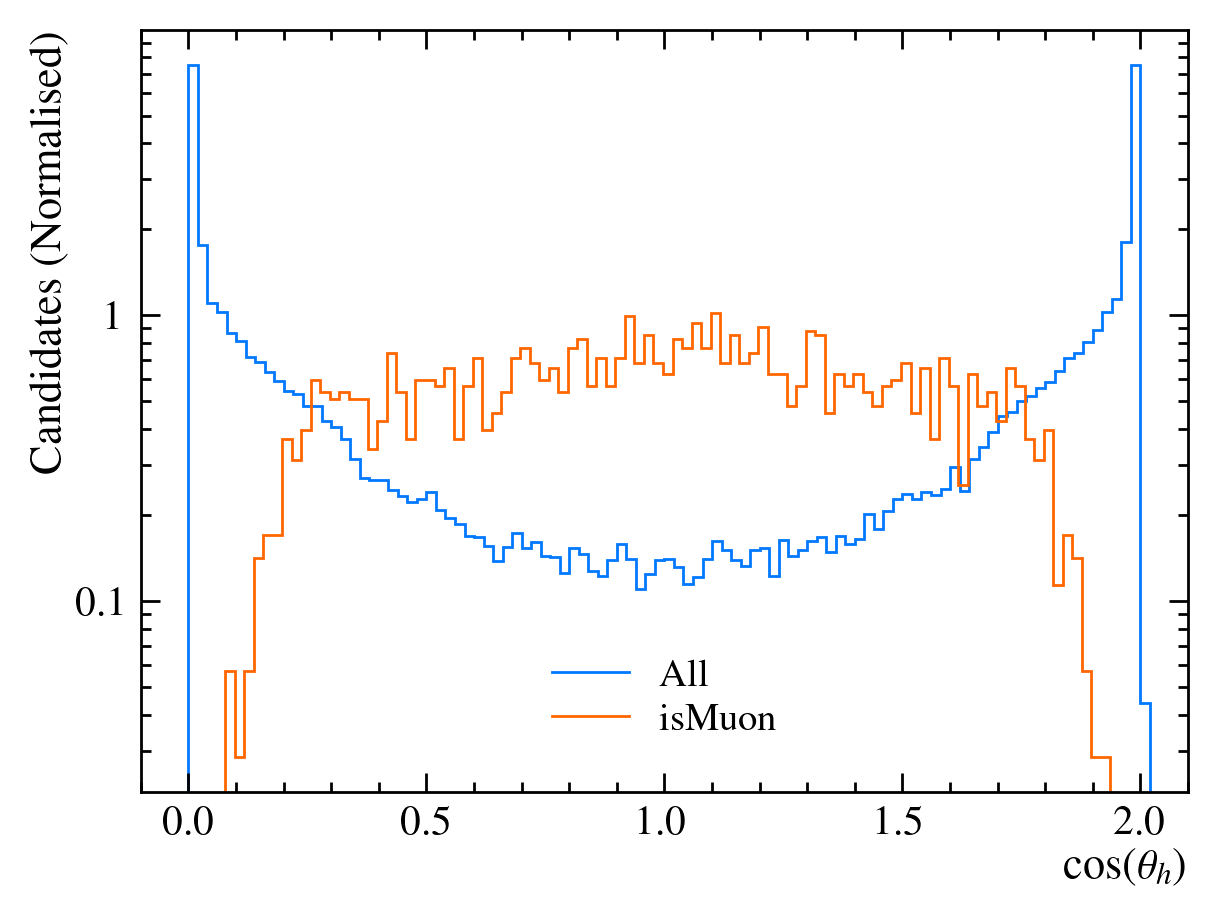

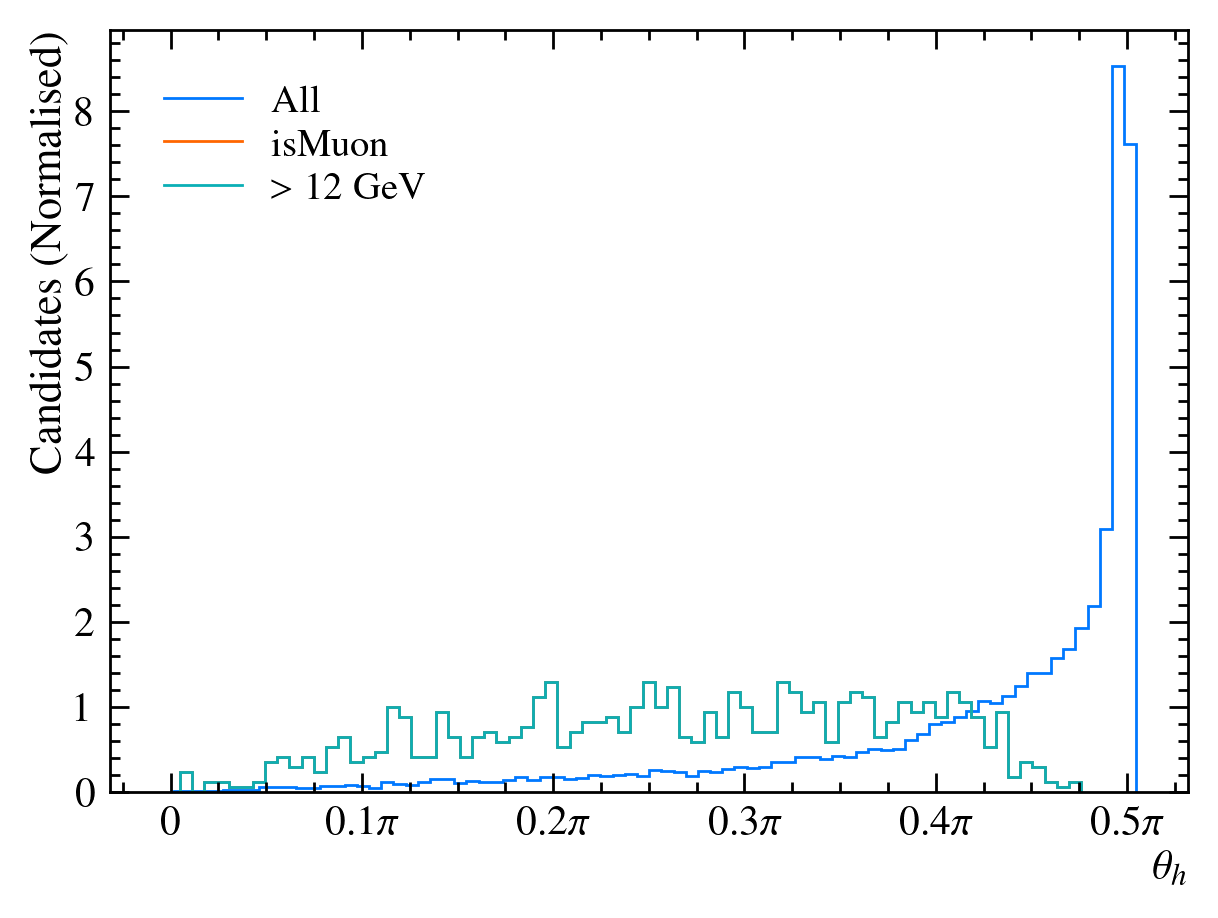

In [9]:
muplus_vector_all = vector.array(
    {
        "px": no_ismuon_df["muplus_PX"],
        "py": no_ismuon_df["muplus_PY"],
        "pz": no_ismuon_df["muplus_PZ"],
        "mass": no_ismuon_df["muplus_M"],
    }
)
muminus_vector_all = vector.array(
    {
        "px": no_ismuon_df["muminus_PX"],
        "py": no_ismuon_df["muminus_PY"],
        "pz": no_ismuon_df["muminus_PZ"],
        "mass": no_ismuon_df["muminus_M"],
    }
)

muplus_vector_background = vector.array(
    {
        "px": background_df["muplus_PX"],
        "py": background_df["muplus_PY"],
        "pz": background_df["muplus_PZ"],
        "mass": background_df["muplus_M"],
    }
)
muminus_vector_background = vector.array(
    {
        "px": background_df["muminus_PX"],
        "py": background_df["muminus_PY"],
        "pz": background_df["muminus_PZ"],
        "mass": background_df["muminus_M"],
    }
)

(cos_helicity_muplus_all, helicity_muplus_all), (
    cos_helicity_muminus_all,
    helicity_muminus_all
) = helicity_angles(muplus_vector_all, muminus_vector_all)

fig, ax = histogram_fig(
    [
        HistogramPlot(
            np.concatenate((cos_helicity_muplus_all, cos_helicity_muminus_all)),
            r"All",
            bins=0.02,
        ),
        HistogramPlot(
            np.concatenate((cos_helicity_muplus, cos_helicity_muminus)),
            r"isMuon",
            bins=0.02,
        ),
    ],
    False,
    xlabel=r"$\cos(\theta_h)$",
    xlim=[-0.1, 2.1],
    density=True,
)
ax.set_yscale("log")

fig, ax = histogram_fig(
    [
        HistogramPlot(
            np.concatenate((helicity_muplus_all, helicity_muminus_all)),
            r"All",
            bins=0.02,
        ),
        HistogramPlot(
            np.concatenate((helicity_muplus, helicity_muminus)),
            r"isMuon",
            bins=0.02,
        ),
        HistogramPlot(
            np.concatenate((helicity_muplus, helicity_muminus)),
            r"$> 12$ GeV",
            bins=0.02,
        ),
    ],
    False,
    xlabel=r"$\theta_h$",
    xlim=[-0.1, np.pi/2 + 0.1],
    density=True,
)
ax_units_pi(ax)
# ax.set_yscale("log")

68
880
Histogram not saved to file


/tmp/ipykernel_2093993/2004014895.py:29: RuntimeWarning: invalid value encountered in arccos
  helicity_angle_1 = np.acos(cos_helicity_angle_1)
/tmp/ipykernel_2093993/2004014895.py:32: RuntimeWarning: invalid value encountered in arccos
  helicity_angle_2 = np.acos(cos_helicity_angle_2)


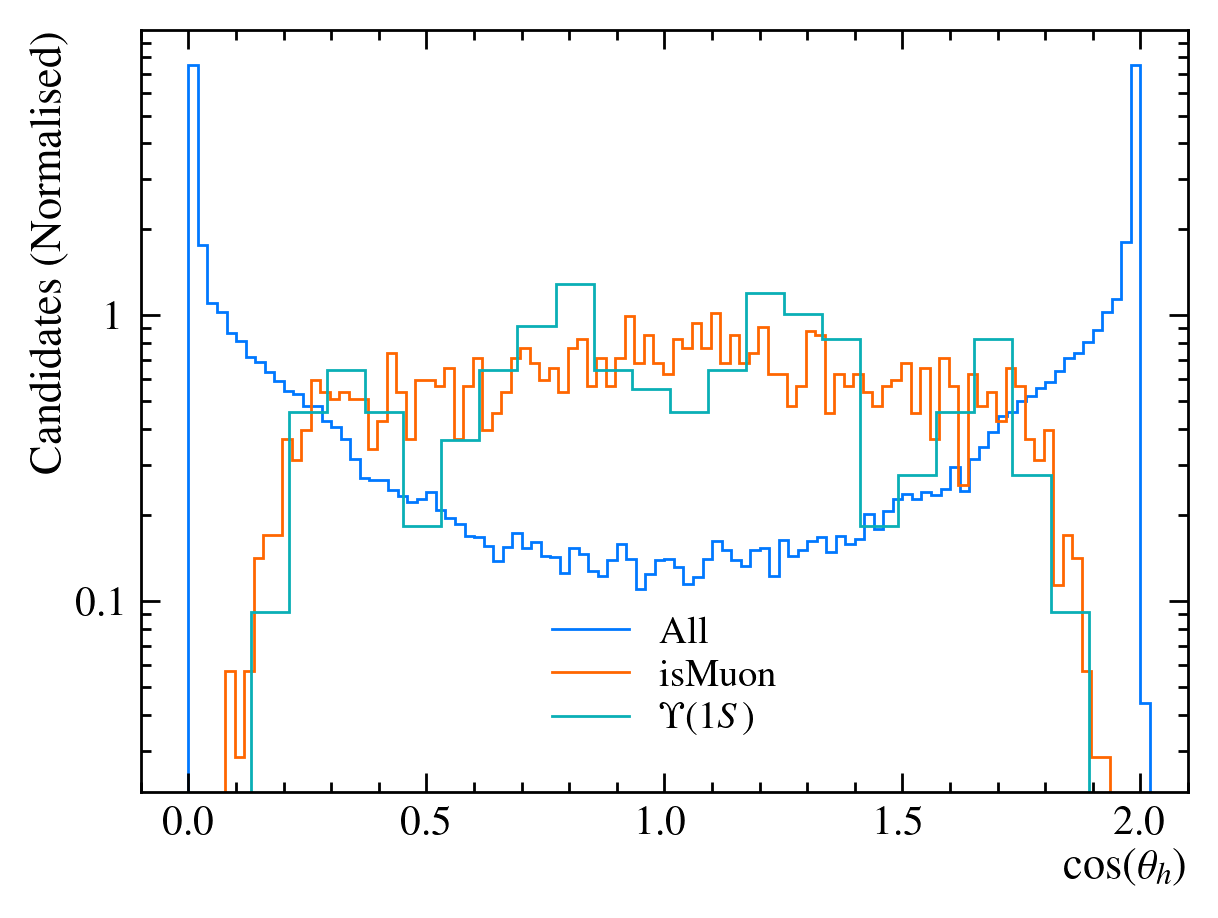

In [10]:
print(len(upsilon_1S_df))
print(len(df))


muplus_vector_Y1S = vector.array(
    {
        "px": upsilon_1S_df["muplus_PX"],
        "py": upsilon_1S_df["muplus_PY"],
        "pz": upsilon_1S_df["muplus_PZ"],
        "mass": upsilon_1S_df["muplus_M"],
    }
)
muminus_vector_Y1S = vector.array(
    {
        "px": upsilon_1S_df["muminus_PX"],
        "py": upsilon_1S_df["muminus_PY"],
        "pz": upsilon_1S_df["muminus_PZ"],
        "mass": upsilon_1S_df["muminus_M"],
    }
)

(cos_muplus_Y1S_helicity, muplus_Y1S_helicity), (
    cos_muminus_Y1S_helicity,
    muminus_Y1S_helicity,
) = helicity_angles(muplus_vector_Y1S, muminus_vector_Y1S)

fig, ax = histogram_fig(
    [
        HistogramPlot(
            np.concatenate((cos_helicity_muplus_all, cos_helicity_muminus_all)),
            r"All",
            bins=0.02,
        ),
        HistogramPlot(
            np.concatenate((cos_helicity_muplus, cos_helicity_muminus)),
            r"isMuon",
            bins=0.02,
        ),
        HistogramPlot(
            np.concatenate((cos_muplus_Y1S_helicity, cos_muminus_Y1S_helicity)),
            r"$\Upsilon(1S)$",
            bins=0.08,
        ),
    ],
    False,
    xlabel=r"$\cos(\theta_h)$",
    xlim=[-0.1, 2.1],
    density=True,
)
ax.set_yscale("log")

In [11]:
# fig, ax = plt.subplots()

# ax.quiver(0, 0, muplus_vector_com.px[0], muplus_vector_com.py[0])
# ax.quiver(0, 0, muminus_vector_com.px[0], muminus_vector_com.py[0])

# fig, ax = plt.subplots()

# ax.quiver(0, 0, muplus_vector_com.px[0], muplus_vector_com.pz[0])
# ax.quiver(0, 0, muminus_vector_com.px[0], muminus_vector_com.pz[0])